In [203]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [204]:
all_data = pd.read_csv('standard.csv')
train_data = all_data[all_data['dataset'] == 'train']
train_x = train_data['x']
train_y = train_data['y']

In [205]:
a = torch.Tensor([60])
a.requires_grad = True
b = torch.Tensor([1300])
b.requires_grad = True

In [206]:
def forward(x):
    return a * x + b


def loss(x_t,y_t) -> torch.Tensor:
    y_p = forward(x_t)
    return (y_p - y_t) ** 2

In [207]:
epoch = 2000
alpha = 0.0001

In [208]:
#利用pytorch实现反向传播算法
for i in range(epoch):
    for x,y in zip(train_x,train_y):
        l = loss(x,y)
        l.backward()
        a.data -= alpha * a.grad.data
        b.data -= alpha * b.grad.data

        a.grad.data.zero_()
        b.grad.data.zero_()

In [209]:
print('a=',a.data,'b=',b.data)

a= tensor([81.7497]) b= tensor([1359.6288])


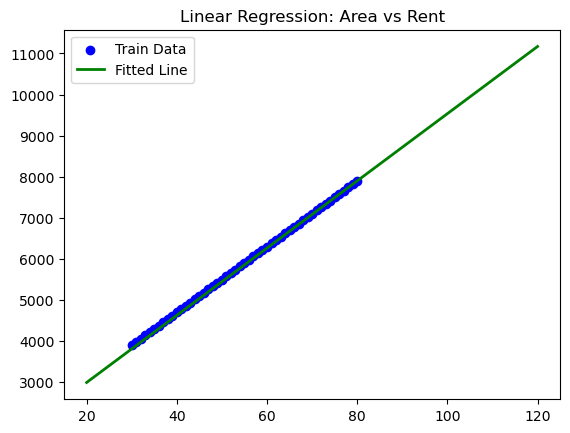

In [210]:
plt.scatter(train_x, train_y, color='blue', label='Train Data')
x_end = np.linspace(20,120,100)
y_end = x_end * float(a.data) + float(b.data)
plt.plot(x_end,y_end,color='green', linewidth=2, label='Fitted Line')
plt.legend()
plt.title('Linear Regression: Area vs Rent')
plt.show()